### Struttura dataset:

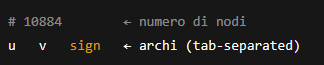

## Codice paper 

In [1]:
from array import array
from scipy.sparse import *
import gc
import networkx as nx


class SignedGraph:

    def __init__(self, dataset_path):
        # nodes
        self.number_of_nodes = 0
        self.nodes_iterator = range(0)

        # adjacency list
        self.adjacency_list = []

        # adjacency matrix and laplacian
        self.a = None
        self.l = None

        # load the dataset
        self.load_dataset(dataset_path)

        # set the dataset path
        self.dataset_path = dataset_path

        # call the garbage collector
        gc.collect()

    def load_dataset(self, dataset_path):
        # open the file
        try:
            dataset_file = open('../datasets/' + dataset_path + '.txt')
        except IOError:
            dataset_file = open('../../datasets/' + dataset_path + '.txt')

        # get the number of nodes from the first line
        self.number_of_nodes = int(dataset_file.readline().replace('# ', ''))
        self.nodes_iterator = range(self.number_of_nodes)

        # create the empty adjacency list
        self.adjacency_list = [[array('i'), array('i')] for _ in self.nodes_iterator]

        # fill the adjacency matrix (0: positive neighbors, 1: negative neighbors)
        for line in dataset_file:
            split_line = line.split('\t')
            from_node = int(split_line[0])
            to_node = int(split_line[1])
            sign = int(split_line[2])

            # add the undirected edge
            self.add_edge(from_node, to_node, sign)

    # add the edge to the adjacency list if it is not a self loop
    def add_edge(self, from_node, to_node, sign):
        if sign == 1:
            sign = 0
        else:
            sign = 1

        if from_node != to_node:
            self.adjacency_list[from_node][sign].append(to_node)
            self.adjacency_list[to_node][sign].append(from_node)

    def get_adjacency_matrix(self):
        if self.a is None:
            self.a = lil_matrix((self.number_of_nodes, self.number_of_nodes), dtype='d')

            for node, neighbors in enumerate(self.adjacency_list):
                for neighbor in neighbors[0]:
                    self.a[node, neighbor] = 1
                for neighbor in neighbors[1]:
                    self.a[node, neighbor] = -1

            self.a = self.a.tocsr()

        return self.a

    def get_signed_laplacian(self):
        if self.l is None:
            self.l = lil_matrix((self.number_of_nodes, self.number_of_nodes), dtype='d')

            # add the inverted signs and the degree on the diagonal
            for node, neighbors in enumerate(self.adjacency_list):
                for neighbor in neighbors[0]:
                    self.l[node, neighbor] = -1
                for neighbor in neighbors[1]:
                    self.l[node, neighbor] = 1
                self.l[node, node] = len(neighbors[0]) + len(neighbors[1])

            self.l = self.l.tocsr()

        return self.l

    def get_signed_laplacian_subgraph(self, nodes):
        # order the nodes
        nodes = list(nodes)
        nodes.sort()

        # get the ordering in a map
        ordering = dict(zip(nodes, range(len(nodes))))

        rows, columns, data = [], [], []
        for node in nodes:
            order = ordering[node]
            degree = 0
            for neighbor in self.adjacency_list[node][0]:
                if neighbor in ordering:
                    rows.append(order)
                    columns.append(ordering[neighbor])
                    data.append(-1)
                    degree += 1
            for neighbor in self.adjacency_list[node][1]:
                if neighbor in ordering:
                    rows.append(order)
                    columns.append(ordering[neighbor])
                    data.append(1)
                    degree += 1
            rows.append(order)
            columns.append(order)
            data.append(degree)

        return coo_matrix((data, (rows, columns)), shape=(len(nodes), len(nodes)), dtype='d').tocsr()

    ### Nuova funzione to_networkx per convertire in grafo NetworkX, in modo da
    ### poter utilizzare funzioni e metodi già esistenti di utilità
    def to_networkx(self):
        """
        Converte l'oggetto SignedGraph in un grafo NetworkX non orientato.
        - Nodi: 0..number_of_nodes-1
        - Archi: con attributo 'sign' = +1 (positivo) o -1 (negativo)
        """
        G = nx.Graph()
        G.add_nodes_from(range(self.number_of_nodes))

        # scorro i nodi
        for u, (pos_neighbors, neg_neighbors) in enumerate(self.adjacency_list):
            # positivi
            for v in pos_neighbors:
                if u < v:  # evita duplicati
                    G.add_edge(u, v, sign=+1)
            # negativi
            for v in neg_neighbors:
                if u < v:
                    G.add_edge(u, v, sign=-1)
                    

        return G

#### Copia della repository

In [2]:

from scipy.sparse.linalg import eigsh
import numpy as np


def evaluate_objective_function(signed_graph, x):
    # special case with no nodes in the solution
    if x.dot(x) == 0:
        return np.nan

    # obtain the adjacency matrix
    a = signed_graph.get_adjacency_matrix()

    # compute the objective function
    a_dot_x = a.dot(x)
    return x.dot(a_dot_x) / x.dot(x)


def build_solution(x):
    # return the nodes having the corresponding index of x different from 0
    return {node for node, element in enumerate(x) if element != 0}


def build_x(signed_graph, nodes, eigenvector=None):
    # get the maximum eigenvector of the adjacency matrix
    if eigenvector is None:
        a = signed_graph.get_adjacency_matrix()
        eigenvector = np.squeeze(eigsh(a, k=1, which='LA')[1])

    # build x from the signs of the minimum eigenvector
    return np.array([np.sign(element) if node in nodes else 0 for node, element in enumerate(eigenvector)])

from algorithms.subroutines.commons import *
from utilities.time_measure import ExecutionTime
from utilities.print_console import print_end_algorithm


def eigensign(signed_graph):
    # start of the algorithm
    execution_time = ExecutionTime()

    # initialize the solution as empty
    solution_x = None
    solution_objective_function = np.finfo(float).min
    solution_threshold = None

    # obtain the adjacency matrix
    a = signed_graph.get_adjacency_matrix()

    # get the eigenvector corresponding to the maximum eigenvalue
    maximum_eigenvector = np.squeeze(eigsh(a, k=1, which='LA')[1])

    # get the thresholds from the eigenvector
    thresholds = {int(np.abs(element) * 1000) / 1000.0 for element in maximum_eigenvector}

    # compute x for all the values of the threshold
    for threshold in thresholds:
        x = np.array([np.sign(element) if np.abs(element) >= threshold else 0 for element in maximum_eigenvector])

        # update the solution if needed
        objective_function = evaluate_objective_function(signed_graph, x)
        if objective_function > solution_objective_function:
            solution_x = x
            solution_objective_function = objective_function
            solution_threshold = threshold

    # build the solution
    solution = build_solution(solution_x)

    # end of the algorithm
    execution_time.end_algorithm()

    # print algorithm's results
    print_end_algorithm(execution_time.execution_time_seconds, solution_x, signed_graph, threshold=solution_threshold)

    # return the solution
    return solution, solution_x


In [3]:

from algorithms.subroutines.commons import *
from utilities.time_measure import ExecutionTime
from utilities.print_console import print_end_algorithm


def random_eigensign(signed_graph, beta, maximum_eigenvector=None, execution_time_seconds=None):
    # start of the algorithm
    execution_time = ExecutionTime()

    if maximum_eigenvector is None:
        # obtain the adjacency matrix
        a = signed_graph.get_adjacency_matrix()

        # get the eigenvector corresponding to the maximum eigenvalue
        maximum_eigenvector = np.squeeze(eigsh(a, k=1, which='LA')[1])

        # consolidate beta
        if beta == 'l1':
            beta = np.linalg.norm(maximum_eigenvector, ord=1)
        elif beta == 'sqrt':
            beta = np.sqrt(signed_graph.number_of_nodes)
        else:
            beta = float(beta)

        # multiply the maximum eigenvector by beta
        maximum_eigenvector *= beta

    # compute x
    x = np.array([0 for _ in signed_graph.nodes_iterator])
    for node, element in enumerate(maximum_eigenvector):
        # check the probability for a certain number of times
        if np.random.choice((True, False), p=(min(np.abs(element), 1), max(1 - np.abs(element), 0))):
            x[node] = np.sign(element)

    # build the solution
    solution = build_solution(x)

    # end of the algorithm
    execution_time.end_algorithm()

    # print algorithm's results
    if execution_time_seconds is None:
        execution_time_seconds = execution_time.execution_time_seconds
    print_end_algorithm(execution_time_seconds, x, signed_graph, beta=beta)

    # return the solution
    return solution, x, maximum_eigenvector, execution_time_seconds, beta


### Prove grafo segnato dai dataset

In [4]:
# DATASET_PATH = "twitterreferendum"

# read the input graph
# signed_graph = SignedGraph(DATASET_PATH)

In [5]:
# G = signed_graph.to_networkx()
# print(G.number_of_nodes(), G.number_of_edges())

In [6]:
# Conta archi positivi e negativi
# positive_edges = sum(1 for _, _, data in G.edges(data=True) if data['sign'] == 1)
# negative_edges = sum(1 for _, _, data in G.edges(data=True) if data['sign'] == -1)

# print(f"Numero di archi positivi: {positive_edges}")
# print(f"Numero di archi negativi: {negative_edges}")

---
# Definizione algoritmo LPA per risolvere problemi 2-PC

In [7]:
from dataclasses import dataclass
import heapq
from typing import Iterable, List, Optional, Set, Tuple
import numpy as np
from scipy.sparse import csr_matrix

# Parametri e stato

@dataclass
class LPAParams:
    allow_flips: bool = True           # se True, abilita flip su nodi già etichettati
    patience: int = 10                 # early stopping se f non migliora per 'patience' mosse accettate
    min_improv: float = 1e-8           # miglioramento minimo per azzerare la pazienza
    max_moves: Optional[int] = None    # tetto di sicurezza sulle mosse accettate (se None, impostato dinamicamente)
    pq_topK: Optional[int] = None      # limita la dimensione massima della PQ (None = illimitata)
    work_on_LCC: bool = True           # se True, lavora sulla LCC (unsigned) prima di partire
    log_every: int = 0                 # >0 per stampare progress ogni N mosse

@dataclass
class LPAState:
    A: csr_matrix          # matrice segnata in CSR --> formato per l'archiviazione di matrici sparse
    x: np.ndarray          # etichette correnti in {-1, 0, +1}
    q: np.ndarray          # q = A x
    g: float               # g = x^T A x
    s: int                 # s = x^T x (# nodi etichettati)
    version: int           # contatore di mosse accettate



In [8]:
# Utility di base

def sign_nonzero(z: float) -> int:
    """Ritorna +1, 0 o -1 come segno classico."""
    if z > 0: return  +1
    if z < 0: return  -1
    return 0

def safe_eval_f(g: float, s: int) -> float:
    """Valuta f=g/s con guardia per s=0. Restituisce -inf se s=0."""
    if s <= 0:
        return float("-inf")
    return g / s

def compute_initial_state(A: csr_matrix, x: np.ndarray) -> LPAState:
    """Costruisce q, g, s, version a partire da A e x."""
    q = A.dot(x)
    g = float(x.dot(q))
    s = int(x.dot(x))
    return LPAState(A=A, x=x, q=q, g=g, s=s, version=0)


In [9]:
# Accesso al grafo (da SignedGraph)

def get_neighbors_with_sign(sg, v: int) -> Iterable[Tuple[int, int]]:
    """
    Iteratore sui vicini (u, sigma) del nodo v.
    sigma = +1 per vicini positivi (insieme S_1), -1 per vicini negativi (insieme S_2).
    """
    pos_neighbors, neg_neighbors = sg.adjacency_list[v]
    for u in pos_neighbors:
        yield (u, +1)
    for u in neg_neighbors:
        yield (u, -1)

def has_labeled_neighbor(sg, x: np.ndarray, v: int) -> bool:
    """True se v ha almeno un vicino con x != 0."""
    for u, _sigma in get_neighbors_with_sign(sg, v):
        if x[u] != 0:
            return True
    return False


In [10]:
# Δf locali (stima ed esatte)

def estimate_add_gain(v: int, state: LPAState) -> Tuple[int, float]:
    """
    Stima del best add-gain per un nodo non etichettato:
    sceglie b = sign(q_v); se q_v = 0 restituisce un guadagno <= 0 (verrà scartato).
    Ritorna (b, estimated_gain).
    """
    s, g, qv = state.s, state.g, state.q[v]
    if s == 0:
        # primo inserimento: massimizza 2*b*qv
        b = +1 if qv >= 0 else -1
        return b, 2.0 * b * qv
    if qv > 0:
        # Δf = (2*qv*s - g) / (s*(s+1))
        return +1, (2.0 * qv * s - g) / (s * (s + 1))
    elif qv < 0:
        return -1, (-2.0 * qv * s - g) / (s * (s + 1))
    else:
        # se qv = 0, questa mossa raramente migliora f (stimiamo -g/(s*(s+1)) <= 0)
        return +1, (-g) / (s * (s + 1)) if s > 0 else 0.0

def exact_add_gain(v: int, b: int, state: LPAState) -> Tuple[float, float, int]:
    """
    Δf esatto per passare da x[v]=0 a x[v]=b in {+1,-1}.
    Ritorna (Δf, Δg, Δs).
    """
    qv = state.q[v]
    delta_g = 2.0 * b * qv
    delta_s = 1
    if state.s == 0:
        # f' = (g+Δg)/(s+1) con g=0,s=0 => f' = Δg/1 = Δg
        return delta_g, delta_g, delta_s
    delta_f = (delta_g * state.s - state.g * delta_s) / (state.s * (state.s + delta_s))
    return delta_f, delta_g, delta_s

def estimate_flip_gain(v: int, state: LPAState) -> float:
    """
    Stima del flip-gain per un nodo etichettato: a = x[v], b = -a.
    Δf = (-4*a*qv)/s (se s>0).
    """
    if state.s == 0:
        return float("-inf")
    a = state.x[v]
    qv = state.q[v]
    return (-4.0 * a * qv) / state.s

def exact_flip_gain(v: int, state: LPAState) -> Tuple[float, float, int]:
    """
    Δf esatto per flippare v: b = -x[v].
    Ritorna (Δf, Δg, Δs) con Δs = 0.
    """
    if state.s == 0:
        return float("-inf"), 0.0, 0
    a = state.x[v]
    qv = state.q[v]
    delta_g = -4.0 * a * qv
    delta_s = 0
    delta_f = delta_g / state.s
    return delta_f, delta_g, delta_s


In [11]:

# Applicazione mossa & aggiornamenti locali

def apply_move(sg, v: int, b: int, state: LPAState):
    """
    Applica la mossa (a -> b) su v, aggiornando x, g, s e q localmente.
    Nota: q[v] NON dipende da x[v] (A[v,v]=0), quindi non va aggiornato.
    """
    a = int(state.x[v])
    if a == b:
        return

    # aggiorna g e s con i delta già calcolati dal chiamante?
    # Qui per robustezza, li ricalcoliamo per consistenza:
    if a == 0:
        # add
        delta_g = 2.0 * b * state.q[v]
        delta_s = 1
    else:
        # flip
        delta_g = -4.0 * a * state.q[v]
        delta_s = 0

    state.x[v] = b
    state.g += delta_g
    state.s += delta_s

    # aggiorna q(u) per i vicini u di v: q[u] += A[u,v] * (b - a)
    delta = b - a
    if delta != 0:
        for u, sigma_uv in get_neighbors_with_sign(sg, v):
            state.q[u] += sigma_uv * delta

    # versione++ per invalidare le stime stale nella PQ
    state.version += 1


# Frontier & Priority Queue (CELF-like)

class CELFPQ:
    """
    Max-heap lazy: memorizza voci (key, v, move_type, move_label, version_snapshot).
    heapq è un min-heap, quindi usiamo key_neg = -key per il max.
    """
    __slots__ = ("heap", "size_cap")

    def __init__(self, size_cap: Optional[int] = None):
        self.heap: List[Tuple[float, int, str, int, int]] = []
        self.size_cap = size_cap

    def push(self, key: float, v: int, move_type: str, move_label: int, version: int):
        entry = (-key, v, move_type, move_label, version)
        heapq.heappush(self.heap, entry)
        if self.size_cap is not None and len(self.heap) > self.size_cap:
            # rimuove l'entry "peggiore" (chiave massima negativa => key più piccolo)
            heapq.heappop(self.heap)

    def pop_max(self) -> Optional[Tuple[float, int, str, int, int]]:
        if not self.heap:
            return None
        key_neg, v, move_type, move_label, version = heapq.heappop(self.heap)
        return (-key_neg, v, move_type, move_label, version)

    def empty(self) -> bool:
        return len(self.heap) == 0

    def __len__(self):
        return len(self.heap)

def build_frontier_and_pq(sg,
                          state: LPAState,
                          seed_mask: np.ndarray,
                          params: LPAParams) -> CELFPQ:
    """
    Costruisce la frontiera iniziale e popola la PQ con stime Δf.
    - Unlabeled con almeno un vicino etichettato -> candidate "add"
    - Se allow_flips: labeled con potenziale flip -> candidate "flip" (solo se gain stimato > 0)
    """
    n = state.x.shape[0]
    pq = CELFPQ(size_cap=params.pq_topK)

    for v in range(n):
        if seed_mask[v]:
            continue

        xv = state.x[v]
        if xv == 0:
            if has_labeled_neighbor(sg, state.x, v):
                b, est_gain = estimate_add_gain(v, state)
                pq.push(est_gain, v, "add", b, state.version)
        else:
            if params.allow_flips:
                est_gain = estimate_flip_gain(v, state)
                if est_gain > 0:
                    pq.push(est_gain, v, "flip", -xv, state.version)
    return pq

def refresh_candidates_after_move(sg,
                                  moved_v: int,
                                  state: LPAState,
                                  seed_mask: np.ndarray,
                                  params: LPAParams,
                                  pq: CELFPQ):
    """
    Dopo aver applicato una mossa su moved_v, aggiorna la PQ localmente (stile CELF):
    rivaluta SOLO i candidati nel vicinato (moved_v e i suoi vicini).
    """
    # 1) moved_v stesso
    v = moved_v
    if not seed_mask[v]:
        xv = state.x[v]
        if xv == 0:
            if has_labeled_neighbor(sg, state.x, v):
                b, est_gain = estimate_add_gain(v, state)
                pq.push(est_gain, v, "add", b, state.version)
        else:
            if params.allow_flips:
                est_gain = estimate_flip_gain(v, state)
                if est_gain > 0:
                    pq.push(est_gain, v, "flip", -xv, state.version)

    # 2) vicini di moved_v
    for u, _sigma in get_neighbors_with_sign(sg, moved_v):
        if seed_mask[u]:
            continue
        xu = state.x[u]
        if xu == 0:
            if has_labeled_neighbor(sg, state.x, u):
                b, est_gain = estimate_add_gain(u, state)
                pq.push(est_gain, u, "add", b, state.version)
        else:
            if params.allow_flips:
                est_gain = estimate_flip_gain(u, state)
                if est_gain > 0:
                    pq.push(est_gain, u, "flip", -xu, state.version)


In [12]:

# Preprocess & init labels

def largest_connected_component_nodes_unsigned(sg) -> np.ndarray:
    """
    Restituisce l'array (np.ndarray) degli indici dei nodi nella Largest Connected Component,
    considerando il grafo come **non segnato** (usa |A|).
    """
    # costruiamo l'adiacenza non segnata come |A|>0
    A = sg.get_adjacency_matrix()
    A_unsigned = A.copy()
    A_unsigned.data[:] = np.ones_like(A_unsigned.data)  # valori a 1
    # BFS/DFS su sparse: versione semplice via NetworkX se disponibile, altrimenti una DFS manuale
    # Per evitare dipendenze, facciamo una DFS manuale veloce.
    n = A_unsigned.shape[0]
    visited = np.zeros(n, dtype=bool)
    lcc_nodes: List[int] = []
    best_size = 0

    for start in range(n):
        if visited[start]:
            continue
        # stack DFS
        stack = [start]
        comp: List[int] = []
        visited[start] = True
        while stack:
            v = stack.pop()
            comp.append(v)
            row_start = A_unsigned.indptr[v]
            row_end = A_unsigned.indptr[v+1]
            neighbors = A_unsigned.indices[row_start:row_end]
            for u in neighbors:
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        if len(comp) > best_size:
            best_size = len(comp)
            lcc_nodes = comp

    return np.array(sorted(lcc_nodes), dtype=int)

def extract_subgraph_by_nodes(sg, nodes: np.ndarray):
    """
    Ritorna una (sg_sub, mapping) dove sg_sub è un SignedGraph "compatibile"
    che condivide la stessa A in forma submatrice (via slicing CSR) e
    la stessa adjacency_list filtrata ai nodi 'nodes'.
    Per semplicità qui ritorniamo solo (A_sub, adj_sub) sufficienti per l'algoritmo.
    """
    # mappa vecchio->nuovo
    ordering = {int(v): i for i, v in enumerate(nodes)}
    # adjacency_list sub
    adj_sub = []
    for v in nodes:
        pos, neg = sg.adjacency_list[v]
        pos_f = [ordering[u] for u in pos if u in ordering]
        neg_f = [ordering[u] for u in neg if u in ordering]
        adj_sub.append([np.array(pos_f, dtype=int), np.array(neg_f, dtype=int)])

    # A_sub
    A = sg.get_adjacency_matrix().tocsr()
    A_sub = A[nodes, :][:, nodes].tocsr()
    # costruiamo un "wrapper" minimale con i campi che usiamo
    class SGView:
        def __init__(self, A_sub, adj_sub):
            self._A = A_sub
            self.adjacency_list = adj_sub
            self.number_of_nodes = A_sub.shape[0]
        def get_adjacency_matrix(self):
            return self._A
    return SGView(A_sub, adj_sub)

def init_labels(n: int, S_1: Iterable[int], S_2: Iterable[int]) -> np.ndarray:
    x = np.zeros(n, dtype=np.int8)
    for v in S_1:
        x[v] = +1
    for v in S_2:
        x[v] = -1
    return x

def build_seed_mask(n: int, S_1: Iterable[int], S_2: Iterable[int]) -> np.ndarray:
    mask = np.zeros(n, dtype=bool)
    for v in S_1:
        mask[v] = True
    for v in S_2:
        mask[v] = True
    return mask

import numpy as np
from typing import List, Tuple

def sample_seeds(signed_graph, frac: float = 0.01, seed: int = 42) -> Tuple[List[int], List[int]]:
    rng = np.random.default_rng(seed)

    n = signed_graph.number_of_nodes
    num_seeds = max(2, int(frac * n))   # almeno 2 seed
    half = num_seeds // 2

    all_nodes = np.arange(n)
    rng.shuffle(all_nodes)

    S_1 = all_nodes[:half].tolist()
    S_2 = all_nodes[half:num_seeds].tolist()

    print(f"Selected {len(S_1)} seeds for (S_1) and {len(S_2)} seeds for (S_2)")
    
    return S_1, S_2



In [13]:
# MAIN: CELF-like LPA guidata dall'obiettivo 2-PC

def lpa_signed_2pc_celf(signed_graph, S_1: Optional[Iterable[int]] = None, S_2: Optional[Iterable[int]] = None,
                        params: Optional[LPAParams] = None, seed_frac: float = 0.01, seed_random: int = 42):
    """
    Algoritmo LPA semi-supervised CELF-like guidato dalla funzione obiettivo 2-PC (f = x^T A x / x^T x).
    - Usa SignedGraph per A (CSR) e adjacency_list per aggiornamenti locali.
    - I seed sono "clampati" e non cambiano mai.
    - Di default: no flip (allow_flips=False), espansione dai seed.
    """
    if params is None:
        params = LPAParams()

    # 0) Preprocess: LCC (opzionale)
    sg = signed_graph
    # Se non sono stati forniti i seed, estraili casualmente
    if S_1 is None or S_2 is None:
        S_1, S_2 = sample_seeds(signed_graph, frac=seed_frac, seed=seed_random)

    if params.work_on_LCC:
        nodes_lcc = largest_connected_component_nodes_unsigned(signed_graph)
        sg = extract_subgraph_by_nodes(signed_graph, nodes_lcc)
        # rimappi seeds sui nuovi indici
        index_map = {old: new for new, old in enumerate(nodes_lcc)}
        S_1 = [index_map[v] for v in S_1 if v in index_map]
        S_2 = [index_map[v] for v in S_2 if v in index_map]

    n = sg.number_of_nodes
    A = sg.get_adjacency_matrix().tocsr()


    # 1) Init labels & state
    x = init_labels(n, S_1, S_2)
    seed_mask = build_seed_mask(n, S_1, S_2)
    state = compute_initial_state(A, x)

    # 2) Init PQ (frontiera + stime)
    pq = build_frontier_and_pq(sg, state, seed_mask, params)

    # 3) Calcolo max_moves se non specificato, adattato alla dimensione del grafo
    m_est = int(A.nnz // 2)  # archi non orientati stimati (A simmetrica con 2 per edge)
    if params.max_moves is None:
        # tetto ragionevole: fino a 100*n o 20*m (il min)
        params.max_moves = min(100 * n, 20 * m_est)

    # 4) Loop greedy CELF-like
    f_best = safe_eval_f(state.g, state.s)
    patience_ctr = 0
    moves_done = 0

    while not pq.empty():
        top = pq.pop_max()
        if top is None:
            break
        key_est, v, move_type, b, ver_snapshot = top

        # Se l'entry è "stale" (è passata almeno una mossa da quando è stata stimata), ricalcola e reinserisci
        if ver_snapshot < state.version:
            if move_type == "add" and state.x[v] == 0 and not seed_mask[v]:
                # ricalcolo stima (lazy): basta reinserire con estimate attuale
                b_new, est_gain = estimate_add_gain(v, state)
                pq.push(est_gain, v, "add", b_new, state.version)
            elif move_type == "flip" and params.allow_flips and state.x[v] in (+1, -1) and not seed_mask[v]:
                est_gain = estimate_flip_gain(v, state)
                if est_gain > 0:
                    pq.push(est_gain, v, "flip", -state.x[v], state.version)
            continue  # passa al prossimo top

        # Entry nuova in PQ: calcolo Δf esatto
        if move_type == "add":
            if state.x[v] != 0 or seed_mask[v]:
                continue
            delta_f, delta_g, delta_s = exact_add_gain(v, b, state)
        elif move_type == "flip" and params.allow_flips:
            if state.x[v] not in (+1, -1) or seed_mask[v]:
                continue
            delta_f, delta_g, delta_s = exact_flip_gain(v, state)
        else:
            continue

        # Applica solo se migliora davvero
        if delta_f <= 0:
            continue

        # Applica la mossa (aggiorna x,g,s,q,version)
        apply_move(sg, v, b, state)
        moves_done += 1

        # Aggiorna i candidati nella zona impattata dalla mossa
        refresh_candidates_after_move(sg, v, state, seed_mask, params, pq)

        # Early stopping su f
        f_now = safe_eval_f(state.g, state.s)
        if f_now > f_best + params.min_improv:
            f_best = f_now
            patience_ctr = 0
        else:
            patience_ctr += 1

        # Log
        if params.log_every and (moves_done % params.log_every == 0):
            print(f"[moves={moves_done}] f={f_now:.6f}, s={state.s}, pq={len(pq)}")

        # Stop conditions
        if patience_ctr >= params.patience:
            print(f"No improvement in the last {params.patience} moves. Stopping (Patience).")
            break
        if moves_done >= params.max_moves:
            print(f"Reached max_moves={params.max_moves}. Stopping (Max Moves).")
            break    
    if pq.empty():
        print("Priority queue empty. No more improving moves. Stopping (PQ Empty).")

    # Fine: ritorna x, f_best e diagnostica
    diagnostics = {
        "n": n,
        "moves_done": moves_done,
        "final_f": safe_eval_f(state.g, state.s),
        "best_f": f_best,
        "labeled": int(state.s),
        "pq_left": len(pq),
    }
    return state.x, f_best, diagnostics


## Test chiamata sul grafo "twitterreferendum" -> Rimosso

In [14]:
# Parametri


# 1) Carica il grafo segnato (dalla repo del paper)
# DATASET_PATH = "twitterreferendum"  # esempio: "slashdot", "epinions", "twitterreferendum", "bitcoin", "highlandtribes"
# signed_graph = SignedGraph(DATASET_PATH)


In [15]:
# 2) Estrazione automatica dei seed dal grafo 
# --> In uno scenario reale, i seed sarebbero noti a priori

## Integrata estrazione casuale dei seed in lpa_signed_2pc_celf()


In [16]:

# 3) Parametri LPA (default ok per partire)
params = LPAParams(
    allow_flips=True,       # Permette di cambiare etichetta ai nodi già etichettati
    work_on_LCC=False,      # True consigliato per grafi molto sparsi
    patience=500,
    min_improv=1e-8,
    max_moves=None,         # calcolato in base a n e m --> Limitato comunque internamente
    pq_topK=None,           # None = illimitato
    log_every=100           # metti 1000 per logging periodico
)


In [17]:

# 4) Esegui
# x, best_f, diag = lpa_signed_2pc_celf(signed_graph, params=params, seed_frac=0, seed_random=42)

# # oppure, se passo anche i seed vector: S_1, S_2
# # x, best_f, diag = lpa_signed_2pc_celf(signed_graph, S_1, S_2, params=params)



# print("Best f(x):", best_f)
# print("Diagnostics:", diag)
# print("Label counts: +1 =", int((x==1).sum()), " -1 =", int((x==-1).sum()), " 0 =", int((x==0).sum()))

In [18]:
# Info di base sul vettore x
# print("type(x):", type(x), "dtype:", getattr(x, "dtype", None), "shape:", getattr(x, "shape", None))
# print("unique in x:", np.unique(x), "...")
# print("#nonzero:", np.count_nonzero(x))

# # Costruisce gli insiemi S1 (+1) e S2 (-1)
# S_1 = {i for i, val in enumerate(x) if val == 1}
# S_2 = {i for i, val in enumerate(x) if val == -1}

# print("\nS_1 (positivi):", len(S_1), "nodi")
# print("Nodi S_1:", list(S_1)[:20], "..." if len(S_1) > 20 else "")

# print("\nS_2 (negativi):", len(S_2), "nodi")
# print("Nodi S_2:", list(S_2)[:20], "..." if len(S_2) > 20 else "")

### Confronto algoritmo Paper

#### Ottenimento soluzione dagli algoritmi della repo

In [19]:
# f_check = eigensign(signed_graph)

In [20]:
# f_check = random_eigensign(signed_graph, beta='l1')

---
# Test dell'algoritmo sul dataset POLITISKY24

### Prove con seed scelti

In [21]:
import pandas as pd
import numpy as np
import os

DATASET_PATH = "politisky24"
signed_graph = SignedGraph(DATASET_PATH)

# prendo stance per nodi seed da "POLITISKY24_Dataset\llm_annotated_full_user_stance_dataset.parquet"
STANCE_PATH = "../../POLITISKY24_Dataset/llm_annotated_full_user_stance_dataset.parquet"

df_stance = pd.read_parquet(STANCE_PATH)
print("Loaded stance data:", df_stance.shape)

Loaded stance data: (16044, 10)


In [22]:
# --- Mapping e set dei nodi del grafo ---
MAP_PATH = "../../polarized_communities-master/datasets/politisky24.nodes.tsv"
map_df = pd.read_csv(MAP_PATH, sep="\t")
orig_to_idx = {int(r.original_id): int(r.index) for r in map_df.itertuples(index=False)}
ids_in_graph = set(map_df["original_id"].astype(np.int64))
num_nodes = len(map_df)

# --- Parametri ---
CONF_THRESH = 0.60
SEED_FRAC   = 0.01   # 1% del numero totale di nodi
RNG_SEED    = 123

num_seeds_total = max(2, int(SEED_FRAC * num_nodes))
k_pos_target = num_seeds_total // 2
k_neg_target = num_seeds_total - k_pos_target

# --- Filtri su stance (alta confidenza, stance nette) ---
df_st = df_stance.copy()
df_st["ConfidenceLevel"] = pd.to_numeric(df_st["ConfidenceLevel"], errors="coerce")
df_st = df_st[df_st["ConfidenceLevel"] >= CONF_THRESH]
df_st = df_st[~df_st["StanceLabel"].str.lower().isin(["neither", "other"])]

# --- Pool candidati seed (userId ORIGINALI) ---
# POS (+1) = Favor Trump OR Against Harris
cand_pos_all = df_st[
    (
        (df_st["TargetEntity"].str.lower() == "trump") &
        (df_st["StanceLabel"].str.lower() == "favor")
    )
    |
    (
        (df_st["TargetEntity"].str.lower() == "harris") &
        (df_st["StanceLabel"].str.lower() == "against")
    )
]["UserId"].astype(np.int64).unique()

# NEG  (-1) = Favor Harris OR Against Trump
cand_neg_all = df_st[
    (
        (df_st["TargetEntity"].str.lower() == "harris") &
        (df_st["StanceLabel"].str.lower() == "favor")
    )
    |
    (
        (df_st["TargetEntity"].str.lower() == "trump") &
        (df_st["StanceLabel"].str.lower() == "against")
    )
]["UserId"].astype(np.int64).unique()

# --- Tieni solo chi è nel grafo ---
cand_pos = np.array([u for u in cand_pos_all if u in ids_in_graph], dtype=np.int64)
cand_neg = np.array([u for u in cand_neg_all if u in ids_in_graph], dtype=np.int64)

# --- Rendi i due pool DISGIUNTI (se qualche utente è in entrambi) ---
inter = np.intersect1d(cand_pos, cand_neg, assume_unique=False)
if inter.size > 0:
    # rimuovi l'intersezione dal lato più piccolo (per bilanciare un po')
    if cand_pos.size <= cand_neg.size:
        cand_pos = np.setdiff1d(cand_pos, inter, assume_unique=False)
    else:
        cand_neg = np.setdiff1d(cand_neg, inter, assume_unique=False)

print(f"Candidati nel grafo (disgiunti): Trump={len(cand_pos)}  Harris={len(cand_neg)}")

# --- Campiona prima dai candidati; se non bastano, riempi dal resto dei nodi ---
rng = np.random.default_rng(RNG_SEED)
all_nodes_internal = np.arange(num_nodes, dtype=np.int64)
used_internal = set()

# helper per mappare userId -> indice interno
def map_uids_to_internal(uids: np.ndarray) -> np.ndarray:
    return np.array([orig_to_idx[int(uid)] for uid in uids], dtype=np.int64)

# 1) campiona dai candidati (limitati alla quantità richiesta)
k_pos_from_cand = min(k_pos_target, len(cand_pos))
k_neg_from_cand = min(k_neg_target, len(cand_neg))

sel_pos_uids = rng.choice(cand_pos, size=k_pos_from_cand, replace=False) if k_pos_from_cand > 0 else np.array([], dtype=np.int64)
sel_neg_uids = rng.choice(cand_neg, size=k_neg_from_cand, replace=False) if k_neg_from_cand > 0 else np.array([], dtype=np.int64)

S_1 = map_uids_to_internal(sel_pos_uids).tolist()
S_2 = map_uids_to_internal(sel_neg_uids).tolist()
used_internal.update(S_1); used_internal.update(S_2)

# 2) riempi deficit dal resto dei nodi (non candidati e non già usati)
k_pos_def = k_pos_target - len(S_1)
k_neg_def = k_neg_target - len(S_2)

if k_pos_def > 0 or k_neg_def > 0:
    # pool: tutti i nodi interni esclusi quelli già presi
    pool_rest = all_nodes_internal[~np.isin(all_nodes_internal, np.fromiter(used_internal, dtype=np.int64))]

    # riempi pos
    if k_pos_def > 0:
        add_pos = rng.choice(pool_rest, size=min(k_pos_def, len(pool_rest)), replace=False).tolist()
        S_1.extend(add_pos)
        used_internal.update(add_pos)
        pool_rest = pool_rest[~np.isin(pool_rest, np.array(add_pos, dtype=np.int64))]

    # riempi neg
    if k_neg_def > 0:
        add_neg = rng.choice(pool_rest, size=min(k_neg_def, len(pool_rest)), replace=False).tolist()
        S_2.extend(add_neg)
        used_internal.update(add_neg)
        # pool_rest potrebbe non servirti più

# --- Sanity & log finale ---
total = len(S_1) + len(S_2)
print(f"Selected seeds (final): +1={len(S_1)}  -1={len(S_2)}  total={total}  (target={num_seeds_total})")

# --- Check sul grafo corrente ---
A = signed_graph.get_adjacency_matrix()
n = A.shape[0]
print("Graph size n =", n)
assert len(S_1) > 0 and len(S_2) > 0, "Seed vuoti dopo il riempimento."
assert max(S_1 + S_2) < n, "Seed fuori range: mapping non coerente col grafo caricato."


Candidati nel grafo (disgiunti): Trump=358  Harris=6859
Selected seeds (final): +1=409  -1=410  total=819  (target=819)
Graph size n = 81951


In [23]:
# Verifiche sui vettori dei seed
print(num_nodes, len(cand_pos_all), len(cand_neg_all), len(cand_pos), len(cand_neg), len(S_1), len(S_2))

81951 1271 6879 358 6859 409 410


---
# Confronto massiccio su tutti i dataset con i 3 metodi

In [24]:
params = LPAParams(
    allow_flips=True,       # Permette di cambiare etichetta ai nodi già etichettati
    work_on_LCC=False,      # True consigliato per grafi molto sparsi
    patience=500,
    min_improv=1e-8,
    max_moves=None,         # calcolato in base a n e m --> Limitato comunque internamente
    pq_topK=None,           # None = illimitato
    log_every=100           # metti 1000 per logging periodico
)


In [25]:
import os
import numpy as np
import pandas as pd

# Cartella "datasets" un livello sopra la cwd
DATASETS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "datasets"))

rows = []

for fname in sorted(os.listdir(DATASETS_DIR)):
    if fname.startswith('.') or not fname.endswith(".txt"):
        continue  # salta nascosti o non-txt

    dataset_name = os.path.splitext(fname)[0]
    print(f"\n=== Dataset: {dataset_name} ===")

    # 1) Carica grafo segnato con la classe SignedGraph della repo
    signed_graph = SignedGraph(dataset_name)

    # 2.a) LPA 2-PC con seed casuali
    x_lpa, f_lpa, diag_lpa = lpa_signed_2pc_celf(
        signed_graph,
        params=params,
        seed_frac=0.01,
        seed_random=42
    )
    S_lpa = {i for i, v in enumerate(x_lpa) if v != 0}
    rows.append({
        "Dataset": dataset_name,
        "Method": "LPA_2-PC_1%",
        "f(x)": float(f_lpa),
        "|S|": len(S_lpa),
        "|S_1|": x_lpa.tolist().count(1),
        "|S_2|": x_lpa.tolist().count(-1),
    })

    # 2.b) LPA 2-PC con 2 seed
    x_lpa, f_lpa, diag_lpa = lpa_signed_2pc_celf(
        signed_graph,
        params=params,
        seed_frac=0,
        seed_random=42
    )
    S_lpa = {i for i, v in enumerate(x_lpa) if v != 0}
    rows.append({
        "Dataset": dataset_name,
        "Method": "LPA_2-PC_2seeds",
        "f(x)": float(f_lpa),
        "|S|": len(S_lpa),
        "|S_1|": x_lpa.tolist().count(1),
        "|S_2|": x_lpa.tolist().count(-1),
    })

    # 3) EigenSign
    S_eig, x_eig = eigensign(signed_graph)
    f_eig = float(evaluate_objective_function(signed_graph, x_eig))
    rows.append({
        "Dataset": dataset_name,
        "Method": "EigenSign",
        "f(x)": f_eig,
        "|S|": len(S_eig),
        "|S_1|": x_eig.tolist().count(1),
        "|S_2|": x_eig.tolist().count(-1),
    })

    # 4) Random-EigenSign
    S_rand, x_rand, *_ = random_eigensign(signed_graph, beta='l1')
    f_rand = float(evaluate_objective_function(signed_graph, x_rand))
    rows.append({
        "Dataset": dataset_name,
        "Method": "Random EigenSign",
        "f(x)": f_rand,
        "|S|": len(S_rand),
        "|S_1|": x_rand.tolist().count(1),
        "|S_2|": x_rand.tolist().count(-1),
    })


=== Dataset: bitcoin ===
Selected 29 seeds for (S_1) and 29 seeds for (S_2)
[moves=100] f=18.101266, s=158, pq=9994
[moves=200] f=22.705426, s=258, pq=10907
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Selected 1 seeds for (S_1) and 1 seeds for (S_2)
[moves=100] f=27.627451, s=102, pq=9710
Priority queue empty. No more improving moves. Stopping (PQ Empty).
------------- Output ------------
tau:                   0.034
multiplicative factor: nan
runtime:               0.559
polarity:              29.52173913043478
S_1:                   {4405, 3647}
S_2:                   {1537, 3, 5, 7, 2569, 10, 2571, 2062, 16, 3603, 5141, 23, 2071, 2583, 1564, 542, 3617, 3618, 1571, 36, 38, 3116, 1581, 3630, 50, 1589, 3638, 1594, 60, 2115, 1607, 4169, 2125, 4183, 1624, 93, 4201, 2154, 1643, 2675, 3704, 4733, 1662, 127, 1154, 3724, 4240, 145, 1684, 3735, 2206, 159, 680, 3242, 172, 2225, 3261, 1726, 2238, 3775, 2243, 2256, 1745, 3793, 2778, 4316, 3812, 237, 2285, 1778, 1272, 178

C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  return -1, (-2.0 * qv * s - g) / (s * (s + 1))
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  return +1, (2.0 * qv * s - g) / (s * (s + 1))
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  delta_f = (delta_g * state.s - state.g * delta_s) / (state.s * (state.s + delta_s))


[moves=200] f=171.000000, s=2, pq=303879
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Selected 1 seeds for (S_1) and 1 seeds for (S_2)
[moves=100] f=59.450980, s=102, pq=266906
[moves=200] f=94.148515, s=202, pq=328508
[moves=300] f=129.350993, s=302, pq=348058
[moves=400] f=166.398010, s=402, pq=357257
[moves=500] f=184.956175, s=502, pq=349369
Priority queue empty. No more improving moves. Stopping (PQ Empty).
------------- Output ------------
tau:                   0.008
multiplicative factor: nan
runtime:               7.947
polarity:              175.65356265356266
S_1:                   {62, 6245, 2158, 6256, 151, 152, 6306, 171, 188, 6358, 6360, 6363, 6364, 6369, 6370, 6371, 6372, 6373, 232, 6376, 234, 235, 236, 237, 238, 239, 6378, 6379, 242, 243, 6380, 245, 246, 247, 6383, 249, 6385, 251, 252, 6388, 6389, 6390, 6391, 6393, 6394, 6396, 6397, 6398, 6399, 6402, 6403, 6404, 6405, 6406, 6412, 4365, 6414, 6415, 6416, 6417, 6418, 389, 390, 391, 392, 393, 394, 3

---
# Utilizzo di LPA attraverso run multipli

### Integrazione di un orchestratore per LPA 2-PC

In [26]:
import numpy as np
import pandas as pd
from typing import Optional, Iterable, Tuple, List, Dict, Any

def _sample_unique(rng, pool: np.ndarray, k: int, exclude: set) -> List[int]:
    """Campiona fino a k elementi unici da pool escludendo 'exclude'."""
    if k <= 0 or pool.size == 0:
        return []
    mask = ~np.isin(pool, np.fromiter(exclude, dtype=pool.dtype)) if exclude else np.ones_like(pool, dtype=bool)
    pool_f = pool[mask]
    if pool_f.size == 0:
        return []
    k_eff = min(k, pool_f.size)
    return rng.choice(pool_f, size=k_eff, replace=False).tolist()

def _build_seeds_for_fraction(n: int,
                              frac: float,
                              rng: np.random.Generator,
                              candidates_pos: Optional[Iterable[int]],
                              candidates_neg: Optional[Iterable[int]]) -> Tuple[List[int], List[int]]:
    """
    Costruisce (S_1, S_2) per la frazione 'frac'.
    - frac == 0  -> esattamente 1 + 1
    - altrimenti -> floor(frac*n) tot (>=2), divisi ~ metà/metà
    Se i candidati non bastano, riempie dai restanti nodi.
    """
    if frac == 0:
        k_total = 2
    else:
        k_total = max(2, int(frac * n))
    # split ~metà/metà
    k_pos = k_total // 2
    k_neg = k_total - k_pos

    # pool globali
    all_nodes = np.arange(n, dtype=int)

    # pool candidati (se forniti)
    cand_pos = np.array(sorted(set(candidates_pos))) if candidates_pos is not None else np.array([], dtype=int)
    cand_neg = np.array(sorted(set(candidates_neg))) if candidates_neg is not None else np.array([], dtype=int)

    # 1) prova a prendere dai candidati
    used = set()
    S_1 = _sample_unique(rng, cand_pos, k_pos, used)
    used.update(S_1)
    S_2 = _sample_unique(rng, cand_neg, k_neg, used)
    used.update(S_2)

    # 2) se non bastano, riempi dal resto dei nodi
    if len(S_1) < k_pos:
        need = k_pos - len(S_1)
        fill = _sample_unique(rng, all_nodes, need, used)
        S_1.extend(fill)
        used.update(fill)
    if len(S_2) < k_neg:
        need = k_neg - len(S_2)
        fill = _sample_unique(rng, all_nodes, need, used)
        S_2.extend(fill)
        used.update(fill)

    # Safety: non vuoti
    if len(S_1) == 0 or len(S_2) == 0:
        # Fallback estremo: se proprio non c'è modo, prendi uno a caso per lato
        pool_rest = np.setdiff1d(all_nodes, np.fromiter(used, dtype=int), assume_unique=False)
        if len(S_1) == 0 and pool_rest.size > 0:
            S_1.append(int(rng.choice(pool_rest)))
        if len(S_2) == 0 and pool_rest.size > 1:
            # evitiamo collisione con pos
            pool_rest = np.setdiff1d(pool_rest, np.array(S_1, dtype=int), assume_unique=False)
            if pool_rest.size > 0:
                S_2.append(int(rng.choice(pool_rest)))

    return S_1, S_2


In [27]:
def lpa_2pc_orchestrator(signed_graph, params, *, fractions: Tuple[float, ...] = (0, 0.01, 0.05, 0.1, 0.2, 0.5),
    candidates_pos: Optional[Iterable[int]] = None, candidates_neg: Optional[Iterable[int]] = None,base_seed: int = 42,repeats: int = 10
) -> Tuple[np.ndarray, float, Dict[str, Any], pd.DataFrame]:
    """
    Orchestratore: esegue LPA-2PC sulle percentuali di nodi seed in 'fractions' e restituisce la migliore soluzione.

    Return di:
      - x_best, f_best, meta_best (dict con frazione e info), df_runs (riepilogo tutte le run)
    """
    A = signed_graph.get_adjacency_matrix()
    n = A.shape[0]

    rows = []
    best_global = None  # (f, x, meta)

    for fi, frac in enumerate(fractions):
        best_frac = None  # (f, x, meta)
        f_vals = []

        print(f"\"\n--- Fraction {frac:.2%} ({fi+1}/{len(fractions)}) ---")
        for r in range(repeats):
            # RNG indipendente per (frac, repeat) ma riproducibile
            ss = np.random.SeedSequence([base_seed, fi, r])
            rng = np.random.default_rng(ss.generate_state(1)[0])

            # Costruisci seed per questa frazione
            S_1, S_2 = _build_seeds_for_fraction(
                n=n, frac=frac, rng=rng,
                candidates_pos=candidates_pos,
                candidates_neg=candidates_neg
            )

            # Run LPA-2PC
            x, f_val, diag = lpa_signed_2pc_celf(
                signed_graph,
                S_1=S_1,
                S_2=S_2,
                params=params
            )

            f_vals.append(float(f_val))
            rows.append({
                "fraction": frac,
                "repeat": r,
                "|S_1|": len(S_1),
                "|S_2|": len(S_2),
                "f(x)": float(f_val),
                "labeled": int((x != 0).sum()),
                "moves_done": diag.get("moves_done", None)
            })

            if (best_frac is None) or (f_val > best_frac[0]):
                best_frac = (float(f_val), x, {
                    "fraction": frac,
                    "repeat": r,
                    "|S_1|": len(S_1),
                    "|S_2|": len(S_2),
                    "diag": diag
                })

        # riepilogo per frazione (per eventuale analisi post)
        rows.append({
            "fraction": frac,
            "repeat": "SUMMARY",
            "|S_1|": len(S_1),
            "|S_2|": len(S_2),
            "f(x)": float(np.max(f_vals)),
            "f_mean": float(np.mean(f_vals)),
            "f_std": float(np.std(f_vals)),
            "labeled": int((best_frac[1] != 0).sum()) if best_frac is not None else 0,
            "moves_done":  best_frac[2]["diag"].get("moves_done", None) if best_frac is not None else None
        })

        # aggiorna best globale
        if (best_global is None) or (best_frac[0] > best_global[0]):
            best_global = best_frac

    df_runs = pd.DataFrame(rows)
    x_best, f_best, meta_best = best_global[1], best_global[0], best_global[2]
    return x_best, f_best, meta_best, df_runs

#### Usage

In [28]:
## Utilizzo:

# Caso A) senza candidati → random su tutto il grafo
# x_best, f_best, meta_best, df_runs = lpa_2pc_orchestrator(
#     signed_graph,
#     params,
#     fractions=(0, 0.01, 0.05, 0.1, 0.2, 0.5),
#     candidates_pos=None,
#     candidates_neg=None,
#     base_seed=123
# )
# print(df_runs)
# print("BEST:", f_best, meta_best)

# Caso B) con candidati (liste di indici interni 0..n-1)
# x_best, f_best, meta_best, df_runs = lpa_2pc_orchestrator_min(
#     signed_graph,
#     params,
#     fractions=(0, 0.01, 0.05, 0.1, 0.2, 0.5),
#     candidates_pos=seed_candidates_pos,
#     candidates_neg=seed_candidates_neg,
#     base_seed=123
# )

### Run con Orchestratore

In [29]:
# params identici per tutte le run multiple
params = LPAParams(
    allow_flips=True,   # o True, come vuoi (uguale per tutte)
    work_on_LCC=False,   # non lo tocchiamo qui
    patience=50,
    min_improv=1e-8,
    max_moves=None,
    pq_topK=None,
    log_every=100
)

In [30]:
# Esecuzione orchestratore su politisky24 con candidati da stance annotata
DATASET_PATH = "politisky24"
signed_graph = SignedGraph(DATASET_PATH)

print(f"\n=== Dataset: {DATASET_PATH} ===")

x_best, f_best, meta_best, df_runs = lpa_2pc_orchestrator(
    signed_graph,
    params,
    fractions=(0, 0.0025, 0.005, 0.01), # 0.05, 0.1), # 0.2, 0.5),
    candidates_pos=S_1,
    candidates_neg=S_2,
    base_seed=42,
    repeats=10
)

print(df_runs[df_runs["repeat"].eq("SUMMARY")][["fraction","f(x)","f_mean","f_std"]])
print("BEST:", f_best, meta_best)

S_lpa = {i for i, v in enumerate(x_best) if v != 0}
rows.append({
    "Dataset": DATASET_PATH,
    "Method": "LPA_2-PC_Orchestrator_Stance",
    "f(x)": f_best,
    "|S|": len(S_lpa),
    "|S_1|": x_best.tolist().count(1),
    "|S_2|": x_best.tolist().count(-1)
})



=== Dataset: politisky24 ===
"
--- Fraction 0.00% (1/4) ---
[moves=100] f=94.529412, s=102, pq=166024
[moves=200] f=180.336634, s=202, pq=295411
[moves=300] f=248.576159, s=302, pq=388427
[moves=400] f=297.940299, s=402, pq=461180
[moves=500] f=332.589641, s=502, pq=511320
[moves=600] f=357.199336, s=602, pq=576528
[moves=700] f=375.253561, s=702, pq=641593
[moves=800] f=387.857855, s=802, pq=686093
[moves=900] f=395.226164, s=902, pq=740743
[moves=1000] f=398.504990, s=1002, pq=769279
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=86.058824, s=102, pq=135966
[moves=200] f=158.207921, s=202, pq=288152
[moves=300] f=223.562914, s=302, pq=421392
[moves=400] f=280.417910, s=402, pq=504480
[moves=500] f=322.039841, s=502, pq=570283
[moves=600] f=351.083056, s=602, pq=622724
[moves=700] f=371.202279, s=702, pq=669905
[moves=800] f=385.131086, s=801, pq=714484
[moves=900] f=393.371809, s=901, pq=765113
[moves=1000] f=397.150849, s=1001, pq=788645
Priority 

C:\Users\jacop\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
"
--- Fraction 1.00% (4/4) ---
[moves=100] f=184.980132, s=151, pq=234048
[moves=200] f=223.274900, s=251, pq=374240
[moves=300] f=269.339031, s=351, pq=488740
[moves=400] f=312.514412, s=451, pq=584001
[moves=500] f=346.123412, s=551, pq=653954
[moves=600] f=370.211982, s=651, pq=697004
[moves=700] f=386.197071, s=751, pq=750497
[moves=800] f=396.451234, s=851, pq=788473
[moves=900] f

In [31]:
# Esecuzione del metodo su tutti i dataset nella cartella "datasets"
for fname in sorted(os.listdir(DATASETS_DIR)):
    if fname.startswith('.') or not fname.endswith(".txt"):
        continue  # salta nascosti o non-txt

    dataset_name = os.path.splitext(fname)[0]
    print(f"\n=== Dataset: {dataset_name} ===")

    # 1) Carica grafo segnato con la classe SignedGraph della repo
    signed_graph = SignedGraph(dataset_name)

    # 2.a) LPA 2-PC (usa auto-seed se non passi seeds)
    x_best, f_best, meta_best, df_runs = lpa_2pc_orchestrator(
        signed_graph,
        params,
        fractions=(0, 0.01, 0.05, 0.1, 0.2, 0.5),
        candidates_pos=None,
        candidates_neg=None,
        base_seed=42,
        repeats=10
    )
    print(df_runs[df_runs["repeat"].eq("SUMMARY")][["fraction","f(x)","f_mean","f_std"]])
    print("BEST:", f_best, meta_best)

    S_lpa = {i for i, v in enumerate(x_best) if v != 0}
    rows.append({
        "Dataset": dataset_name,
        "Method": "LPA_2-PC_Orchestrator",
        "f(x)": f_best,
        "|S|": len(S_lpa),
        "|S_1|": x_best.tolist().count(1),
        "|S_2|": x_best.tolist().count(-1)
    })


# DataFrame finale salvato nella cartella "results" con timestamp
df_results = pd.DataFrame(rows, columns=["Dataset", "Method", "f(x)", "|S|", "|S_1|", "|S_2|"])
df_results = df_results.sort_values(by="Dataset", ascending=True)
print("\n", df_results.to_string(index=False))

OUT_RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "results"))
os.makedirs(OUT_RESULTS_DIR, exist_ok=True)

timestamp = pd.Timestamp.now().strftime("%m%d_%H%M")
file_name = f"comparison_results_{timestamp}.csv"

file_path = os.path.join(OUT_RESULTS_DIR, file_name)
df_results.to_csv(file_path, index=False)


=== Dataset: bitcoin ===
"
--- Fraction 0.00% (1/6) ---
[moves=100] f=27.882353, s=102, pq=9783
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=27.666667, s=102, pq=9793
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=28.156863, s=102, pq=9832
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=25.392157, s=102, pq=9652
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=28.274510, s=102, pq=9538
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=24.392157, s=102, pq=9627
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=27.607843, s=102, pq=9785
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=26.705882, s=102, pq=9907
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=27.882353, s=102, pq=9542
Priority queue empty. No more improving

C:\Users\jacop\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


[moves=100] f=9.830357, s=224, pq=5121
[moves=200] f=11.425926, s=324, pq=5126
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=10.955357, s=224, pq=4944
[moves=200] f=12.574074, s=324, pq=5234
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=7.973214, s=224, pq=4310
[moves=200] f=9.604938, s=324, pq=4465
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=9.348214, s=224, pq=4700
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=11.730942, s=223, pq=5059
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=10.529148, s=223, pq=5035
[moves=200] f=11.671827, s=323, pq=5320
Priority queue empty. No more improving moves. Stopping (PQ Empty).
    fraction       f(x)     f_mean     f_std
10      0.00  29.616438  29.114193  0.485554
21      0.01  23.755952  23.226991  0.267116
32      0.05  24.888031  24.154513  0.393132
43      0.10  23

C:\Users\jacop\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


[moves=100] f=40.019802, s=202, pq=88938
[moves=200] f=68.867550, s=302, pq=127146
[moves=300] f=84.124378, s=402, pq=149192
[moves=400] f=92.398406, s=502, pq=173971
[moves=500] f=98.176080, s=602, pq=201333
[moves=600] f=102.173789, s=702, pq=222538
[moves=700] f=104.905237, s=802, pq=234695
[moves=800] f=106.946785, s=902, pq=251218
[moves=900] f=108.451098, s=1002, pq=263935
[moves=1000] f=109.435572, s=1102, pq=275721
[moves=1100] f=109.945092, s=1202, pq=286413
[moves=1200] f=110.218126, s=1302, pq=295774
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=37.900990, s=202, pq=87056
[moves=200] f=66.774834, s=302, pq=120047
[moves=300] f=82.890547, s=402, pq=145319
[moves=400] f=91.741036, s=502, pq=167918
[moves=500] f=97.820598, s=602, pq=199200
[moves=600] f=102.194009, s=701, pq=217157
[moves=700] f=105.278402, s=801, pq=235616
[moves=800] f=107.276360, s=901, pq=248871
[moves=900] f=108.747253, s=1001, pq=259166
[moves=1000] f=109.714805, s=1101

...

C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:18: RuntimeWarning: invalid value encountered in scalar divide
  return -1, (-2.0 * qv * s - g) / (s * (s + 1))
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return +1, (2.0 * qv * s - g) / (s * (s + 1))


Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
    fraction        f(x)      f_mean     f_std
10      0.00  188.849624  187.023931  1.255957
21      0.01        -inf        -inf       NaN
32      0.05        -inf        -inf       NaN
43      0.10        -inf        -inf       NaN
54      0.20  155.884328  142.373761  9.002374
65      0.50  193.000000        -inf       NaN
BEST: 193.0 {'fraction': 0.5, 'repeat': 5, '|S_1|': 29179, '|S_2|': 29179, 'diag': {'n': 116717, 'moves_done': 14, 'final_f': np.float64(193.0), 'best_f': np.float64(193.0), 'labeled': 2, 'pq_left': 0}}

=== Dataset: wikielections ===
"
--- Fraction 0.00% (1/6) ---
[moves=100] f=40.862745, s=102, pq=19978
[moves=200] f=57.910891,

C:\Users\jacop\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  return -1, (-2.0 * qv * s - g) / (s * (s + 1))
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  return +1, (2.0 * qv * s - g) / (s * (s + 1))
C:\Users\jacop\AppData\Local\Temp\ipykernel_9608\1154632978.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  delta_f = (delta_g * state.s - state.g * delta_s) / (state.s * (state.s + delta_s))


No improvement in the last 50 moves. Stopping (Patience).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
No improvement in the last 50 moves. Stopping (Patience).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
No improvement in the last 50 moves. Stopping (Patience).
"
--- Fraction 50.00% (6/6) ---
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=41.235294, s=68, pq=10605
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
[moves=100] f=29.424242, s=66, pq=9493
[moves=200] f=38.331288, s=163, pq=14931
[moves=300] f=41.409962, s=261, pq=18013
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty. No more improving moves. Stopping (PQ Empty).
Priority queue empty.

C:\Users\jacop\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
